In [10]:
import os
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader, Dataset
from torchvision.utils import save_image
import matplotlib.pyplot as plt
from claude_loader import EnhancedAstroSRDataset, train_two_stage
from claude_model import EnhancedSuperResolution

In [11]:
# # Paths to your numpy files
mer_train_path = '../data/euclid_MER_cosmos_41px_Y.npy'
jwst_train_path = '../data/jwst_cosmos_69px_F115W.npy'

# # Train the model
# trained_model = train_two_stage(
#     mer_train_path, 
#     jwst_train_path, 
#     val_split=0.2,      # 20% validation split
#     batch_size=8,       # Adjust based on GPU memory
#     num_epochs_stage1=100,  # Epochs in first training stage
#     num_epochs_stage2=100   # Epochs in fine-tuning stage
# )

# # Save the final model
# torch.save(trained_model.state_dict(), 'claude_model.pth')

In [3]:
# trained_model

In [4]:
# torch.save(trained_model.state_dict(), "claude_model.pth")

In [5]:
# def load_model(model_path, device=None):
#     """Load a trained super-resolution model."""
#     if device is None:
#         device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

#     # Initialize model architecture
#     model = EnhancedSuperResolution()
    
#     # Load the trained weights
#     model.load_state_dict(torch.load(model_path, map_location=device))
    
#     # Set to evaluation mode
#     model.eval()
#     model = model.to(device)
    
#     print(f"Model loaded from {model_path}")
#     print(f"Using device: {device}")
    
#     return model

# class TestDataset(Dataset):
#     def __init__(self, mer_path, normalize_method='flux_preserving'):
#         """
#         Dataset for testing super-resolution on low-resolution images.
        
#         Args:
#             mer_path (str): Path to the MER numpy file (.npy) with shape [N, 41, 41]
#             normalize_method (str): Normalization method to use
#         """
#         # Load numpy array
#         self.mer_data = np.load(mer_path)
        
#         # Verify shape
#         assert self.mer_data.shape[1:] == (41, 41), f"MER images should be 41x41, got {self.mer_data.shape[1:]}"
        
#         self.normalize_method = normalize_method
#         self.num_samples = self.mer_data.shape[0]
    
#     def __len__(self):
#         return self.num_samples
    
#     def normalize_data(self, img):
#         """Apply normalization to image and return normalization parameters."""
        
#         if self.normalize_method == 'none':
#             return img, {'method': 'none'}
            
#         elif self.normalize_method == 'flux_preserving' or self.normalize_method == 'minmax':
#             # Min-max normalization
#             min_val = np.min(img)
#             max_val = np.max(img)
#             range_val = max_val - min_val
#             if range_val == 0:
#                 return np.zeros_like(img), {'method': 'minmax', 'min': min_val, 'max': max_val}
            
#             normalized = (img - min_val) / range_val
#             return normalized, {'method': 'minmax', 'min': min_val, 'max': max_val}
            
#         elif self.normalize_method == 'zscore':
#             # Z-score normalization
#             mean = np.mean(img)
#             std = np.std(img)
#             if std == 0:
#                 return np.zeros_like(img), {'method': 'zscore', 'mean': mean, 'std': std}
            
#             normalized = (img - mean) / std
#             return normalized, {'method': 'zscore', 'mean': mean, 'std': std}
            
#         else:
#             raise ValueError(f"Unknown normalization method: {self.normalize_method}")
    
#     def __getitem__(self, idx):
#         # Get the image at index idx
#         mer_img = self.mer_data[idx].astype(np.float32)
        
#         # Original image (unnormalized) for reference
#         original_img = mer_img.copy()
        
#         # Apply normalization and get normalization parameters
#         mer_norm, norm_params = self.normalize_data(mer_img)
        
#         # Convert to tensor and add channel dimension
#         mer_tensor = torch.from_numpy(mer_norm).unsqueeze(0)  # Shape: [1, 41, 41]
        
#         return mer_tensor, original_img, norm_params

# def run_inference(model, test_loader, output_dir='sr_results', save_comparison=True, 
#                   save_individual=True, save_denormalized=True, max_samples=10):
#     """
#     Run inference on test images and save/visualize results.
    
#     Args:
#         model: The loaded super-resolution model
#         test_loader: DataLoader with test images
#         output_dir: Directory to save results
#         save_comparison: Whether to save side-by-side comparisons
#         save_individual: Whether to save individual super-resolved images
#         save_denormalized: Whether to save denormalized images
#         max_samples: Maximum number of samples to process (for visualization)
#     """
#     device = next(model.parameters()).device
    
#     os.makedirs(output_dir, exist_ok=True)
#     if save_denormalized:
#         os.makedirs(f"{output_dir}/denormalized", exist_ok=True)
    
#     with torch.no_grad():
#         for i, (lr_image, original_img, norm_params) in enumerate(test_loader):
#             if i >= max_samples:
#                 break
                
#             # Move input to device
#             lr_image = lr_image.to(device)
            
#             # Super-resolve image
#             sr_image = model(lr_image)
            
#             # Move back to CPU for visualization
#             lr_image = lr_image.cpu()
#             sr_image = sr_image.cpu()
            
#             # Save normalized SR image
#             if save_individual:
#                 save_image(sr_image, f"{output_dir}/sr_image_{i}.png", normalize=True)
            
#             # Denormalize the super-resolved image for scientific analysis
#             if save_denormalized:
#                 # Convert to numpy for denormalization
#                 sr_numpy = sr_image[0, 0].numpy()
                
#                 # Denormalize back to original scale
#                 denorm_sr = denormalize(sr_numpy, norm_params[0])
                
#                 # Save denormalized image
#                 plt.figure(figsize=(8, 8))
#                 plt.imshow(denorm_sr, cmap='gray')
#                 plt.colorbar(label='Original Intensity')
#                 plt.title("Denormalized Super-Resolution")
#                 plt.axis('off')
#                 plt.tight_layout()
#                 # plt.savefig(f"{output_dir}/denormalized/denorm_sr_{i}.png", dpi=300, bbox_inches='tight')
#                 plt.close()
                
#                 # Also save the original low-res image for comparison
#                 plt.figure(figsize=(8, 8))
#                 plt.imshow(original_img[0], cmap='gray')
#                 plt.colorbar(label='Original Intensity')
#                 plt.title("Original Low-Resolution")
#                 plt.axis('off')
#                 plt.tight_layout()
#                 # plt.savefig(f"{output_dir}/denormalized/original_{i}.png", dpi=300, bbox_inches='tight')
#                 plt.close()
            
#             # Create comparison visualization
#             if save_comparison:
#                 fig, axes = plt.subplots(1, 3 if save_denormalized else 2, figsize=(15 if save_denormalized else 12, 5))
                
#                 # Plot low-resolution image (normalized)
#                 axes[0].imshow(lr_image[0, 0].numpy(), cmap='gray')
#                 axes[0].set_title(f"Low Resolution (41×41)\nNormalized")
#                 axes[0].axis('off')
                
#                 # Plot super-resolved image (normalized)
#                 axes[1].imshow(sr_image[0, 0].numpy(), cmap='gray')
#                 axes[1].set_title(f"Super Resolution (69×69)\nNormalized")
#                 axes[1].axis('off')
                
#                 # If saving denormalized, add to comparison
#                 if save_denormalized:
#                     sr_numpy = sr_image[0, 0].numpy()
#                     denorm_sr = denormalize(sr_numpy, norm_params[0])
#                     axes[2].imshow(denorm_sr, cmap='gray')
#                     axes[2].set_title(f"Super Resolution (69×69)\nDenormalized")
#                     axes[2].axis('off')
                
#                 plt.tight_layout()
#                 plt.savefig(f"{output_dir}/comparison_{i}.png", dpi=300, bbox_inches='tight')
#                 plt.show()
#                 # plt.close()
                
#             print(f"Processed image {i+1}/{min(len(test_loader), max_samples)}")
            
#     print(f"Results saved to {output_dir}")

# # Inverse normalization (optional - if you need to convert back to original units)
# def denormalize(sr_image, norm_params):
#     """
#     Convert normalized image back to original scale.
    
#     Args:
#         sr_image: Normalized super-resolved image (numpy array)
#         norm_params: Dictionary with normalization parameters
    
#     Returns:
#         Denormalized image in original intensity scale
#     """
#     method = norm_params.get('method', 'minmax')
    
#     if method == 'none':
#         return sr_image
    
#     elif method == 'minmax':
#         min_val = norm_params['min']
#         max_val = norm_params['max']
#         return sr_image * (max_val - min_val) + min_val
    
#     elif method == 'zscore':
#         mean = norm_params['mean']
#         std = norm_params['std']
#         return sr_image * std + mean
        
#     return sr_image  # Default case

TypeError: string indices must be integers

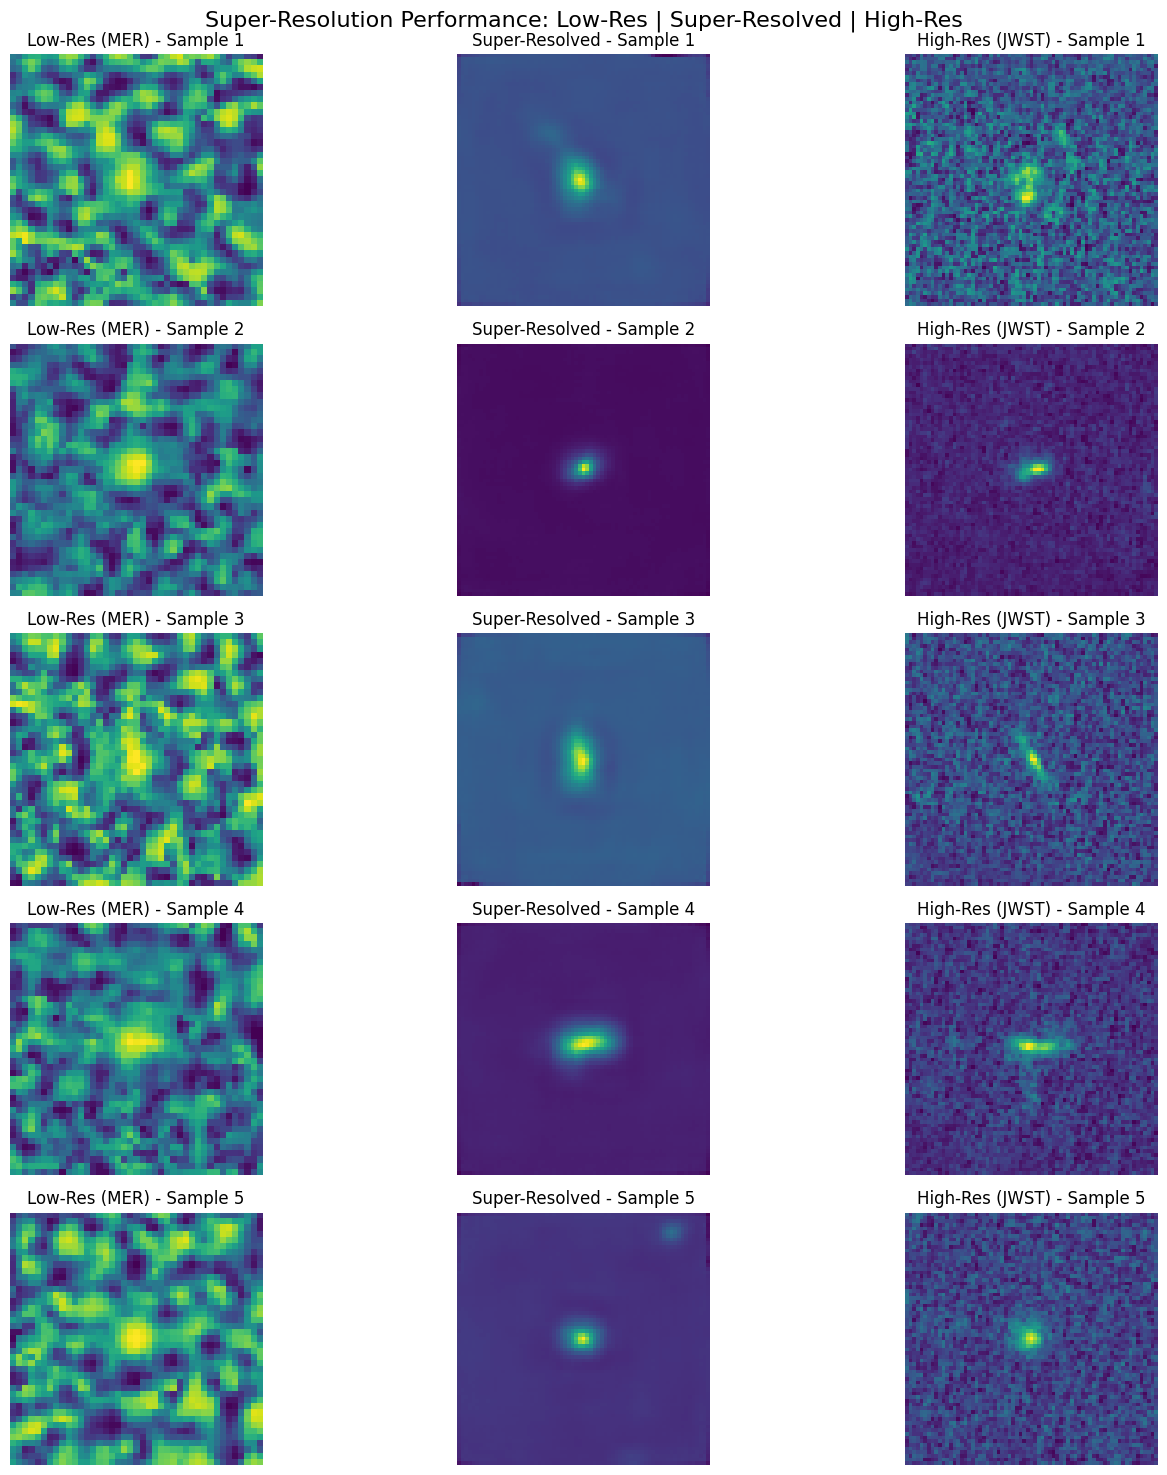

In [9]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def visualize_super_resolution_performance(model, test_loader, num_samples=5, save_path=None):
    """
    Visualize model performance with side-by-side comparisons
    
    Args:
        model: Trained super-resolution model
        test_loader: DataLoader with test images
        num_samples: Number of image sets to visualize
        save_path: Optional path to save the visualization
    """
    # Set model to evaluation mode
    model.eval()
    device = next(model.parameters()).device
    
    # Prepare figure
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 3*num_samples))
    fig.suptitle('Super-Resolution Performance: Low-Res | Super-Resolved | High-Res', fontsize=16)
    
    # Disable gradient computation
    with torch.no_grad():
        for i, (mer_images, jwst_images, norm_params) in enumerate(test_loader):
            if i >= num_samples:
                break
            
            # Move images to device
            mer_images = mer_images.to(device)
            jwst_images = jwst_images.to(device)
            
            # Generate super-resolved image
            sr_images = model(mer_images)
            
            # Move back to CPU for visualization
            mer_images = mer_images.cpu().numpy()
            sr_images = sr_images.cpu().numpy()
            jwst_images = jwst_images.cpu().numpy()
            
            # Denormalize images (if needed)
            def denormalize(img, params):
                method = params['method']
                if method == 'flux_preserving':
                    min_val = params['min_val']
                    max_val = params['max_val']
                    return img * (max_val - min_val) + min_val
                elif method == 'minmax':
                    min_val = params['mer_min']
                    max_val = params['mer_max']
                    return img * (max_val - min_val) + min_val
                return img
            
            # Plot images
            # Low-resolution (MER)
            axes[i, 0].imshow(mer_images[0, 0], cmap='viridis')
            axes[i, 0].set_title(f'Low-Res (MER) - Sample {i+1}')
            axes[i, 0].axis('off')
            
            # Super-resolved
            axes[i, 1].imshow(sr_images[0, 0], cmap='viridis')
            axes[i, 1].set_title(f'Super-Resolved - Sample {i+1}')
            axes[i, 1].axis('off')
            
            # High-resolution (JWST)
            axes[i, 2].imshow(jwst_images[0, 0], cmap='viridis')
            axes[i, 2].set_title(f'High-Res (JWST) - Sample {i+1}')
            axes[i, 2].axis('off')
    
    plt.tight_layout()
    
    # Save or show the plot
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    else:
        plt.show()

def compute_performance_metrics(model, test_loader):
    """
    Compute quantitative performance metrics
    
    Args:
        model: Trained super-resolution model
        test_loader: DataLoader with test images
    
    Returns:
        Dictionary of performance metrics
    """
    from skimage.metrics import peak_signal_noise_ratio, structural_similarity
    
    # Initialize metric accumulators
    psnr_values = []
    ssim_values = []
    
    # Set model to evaluation mode
    model.eval()
    device = next(model.parameters()).device
    
    # Disable gradient computation
    with torch.no_grad():
        for mer_images, jwst_images, norm_params in test_loader:
            # Move images to device
            mer_images = mer_images.to(device)
            jwst_images = jwst_images.to(device)
            
            # Generate super-resolved image
            sr_images = model(mer_images)
            
            # Move back to CPU for metric computation
            sr_images = sr_images.cpu().numpy()
            jwst_images = jwst_images.cpu().numpy()
            
            # Compute metrics for each image in the batch
            for sr, gt, params in zip(sr_images, jwst_images, norm_params):
                # Remove channel dimension
                sr = sr[0]
                gt = gt[0]
                
                # Determine data range based on normalization method
                if params['method'] == 'flux_preserving':
                    # Use the original min and max values
                    data_range = params['max_val'] - params['min_val']
                elif params['method'] == 'minmax':
                    data_range = 1.0  # Normalized images are already in [0, 1]
                else:
                    data_range = np.max(gt) - np.min(gt)
                
                # Compute PSNR
                psnr = peak_signal_noise_ratio(gt, sr, data_range=data_range)
                psnr_values.append(psnr)
                
                # Compute SSIM
                ssim = structural_similarity(
                    gt, 
                    sr, 
                    data_range=data_range,
                    multichannel=False  # Since these are single-channel images
                )
                ssim_values.append(ssim)
    
    # Compute summary statistics
    metrics = {
        'PSNR': {
            'mean': np.mean(psnr_values),
            'std': np.std(psnr_values),
            'min': np.min(psnr_values),
            'max': np.max(psnr_values)
        },
        'SSIM': {
            'mean': np.mean(ssim_values),
            'std': np.std(ssim_values),
            'min': np.min(ssim_values),
            'max': np.max(ssim_values)
        }
    }
    
    return metrics

def create_performance_visualization(metrics):
    """
    Create visualizations of performance metrics
    
    Args:
        metrics: Dictionary of performance metrics
    """
    # Prepare figure
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle('Super-Resolution Performance Metrics', fontsize=16)
    
    # PSNR Boxplot
    sns.boxplot(x=['PSNR'], y=[metrics['PSNR']['mean']], ax=ax1)
    ax1.set_title('Peak Signal-to-Noise Ratio (PSNR)')
    ax1.set_ylabel('PSNR (dB)')
    
    # Add error bars representing std dev
    ax1.errorbar(x=0, y=metrics['PSNR']['mean'], 
                 yerr=metrics['PSNR']['std'], 
                 fmt='o', color='red', capsize=5)
    
    # SSIM Boxplot
    sns.boxplot(x=['SSIM'], y=[metrics['SSIM']['mean']], ax=ax2)
    ax2.set_title('Structural Similarity Index (SSIM)')
    ax2.set_ylabel('SSIM')
    
    # Add error bars representing std dev
    ax2.errorbar(x=0, y=metrics['SSIM']['mean'], 
                 yerr=metrics['SSIM']['std'], 
                 fmt='o', color='red', capsize=5)
    
    plt.tight_layout()
    plt.show()

# Example usage in your main script
def evaluate_model():
    # Load model
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = EnhancedSuperResolution().to(device)
    model.load_state_dict(torch.load('claude_model.pth'))
    
    # Create test dataset and loader
    test_dataset = EnhancedAstroSRDataset(
        '../data/euclid_MER_cosmos_41px_Y.npy', 
        '../data/jwst_cosmos_69px_F115W.npy', 
        normalize_method='adaptive_hist'
    )
    test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)
    
    # Visualize super-resolution performance
    visualize_super_resolution_performance(
        model, 
        test_loader, 
        num_samples=5, 
        save_path='super_resolution_comparison.png'
    )
    
    # Compute performance metrics
    metrics = compute_performance_metrics(model, test_loader)
    
    # Print metrics
    print("Performance Metrics:")
    print("PSNR:")
    for k, v in metrics['PSNR'].items():
        print(f"  {k}: {v:.4f}")
    print("SSIM:")
    for k, v in metrics['SSIM'].items():
        print(f"  {k}: {v:.4f}")
    
    # Visualize metrics
    create_performance_visualization(metrics)

# Run the evaluation
evaluate_model()

Model loaded from claude_model.pth
Using device: cuda


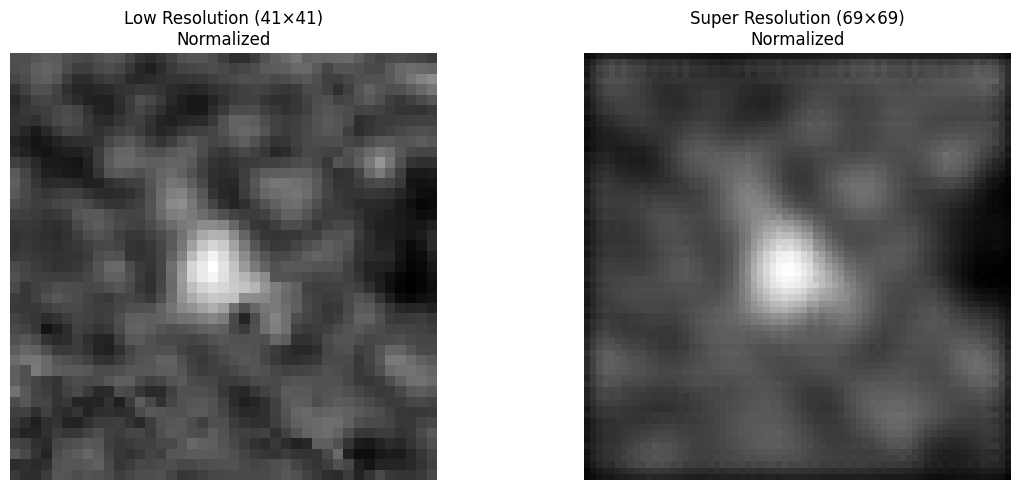

Processed image 1/20


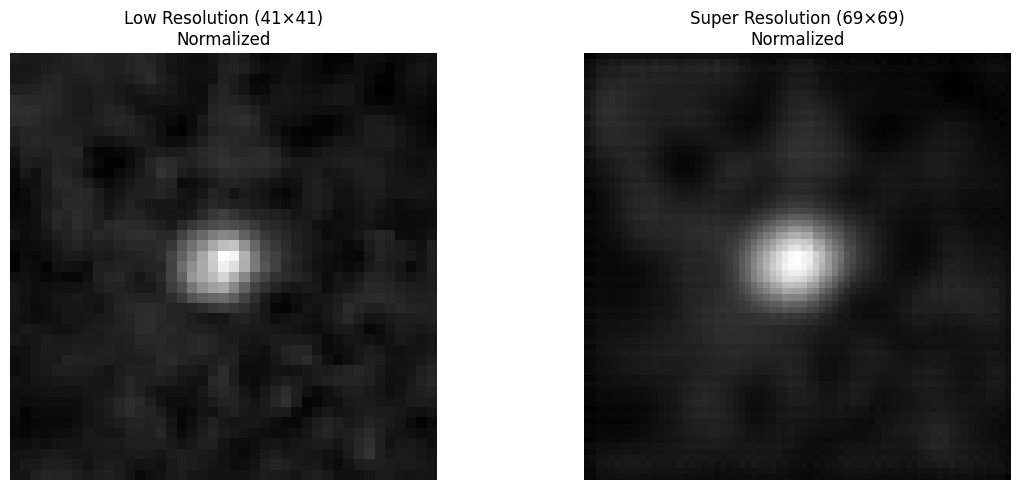

Processed image 2/20


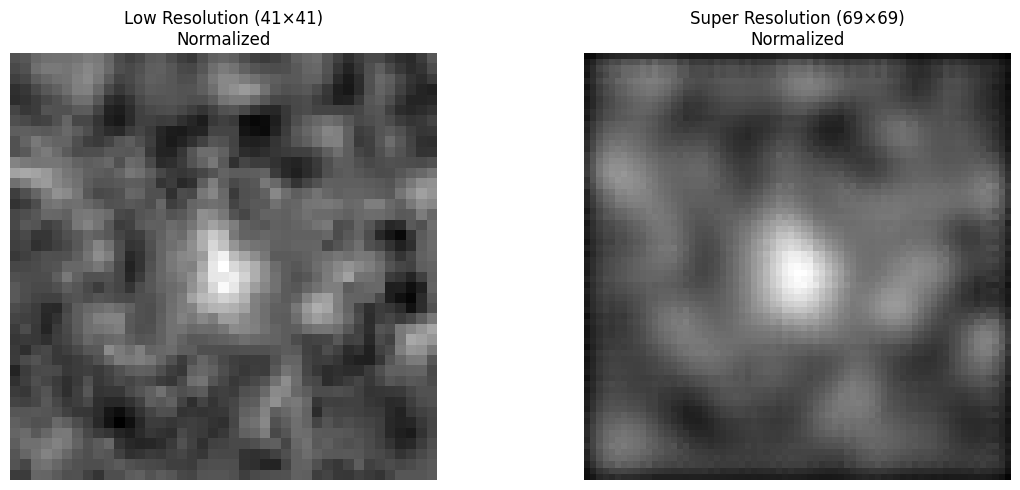

Processed image 3/20


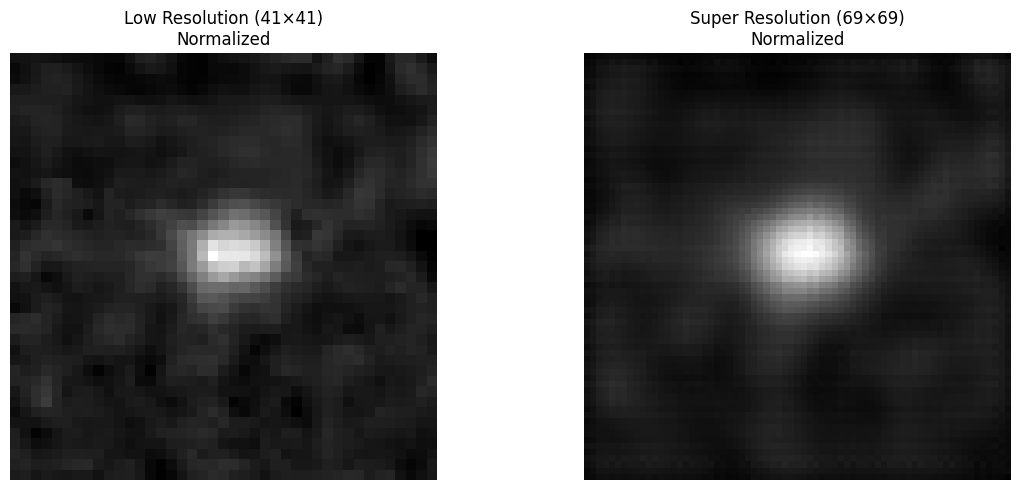

Processed image 4/20


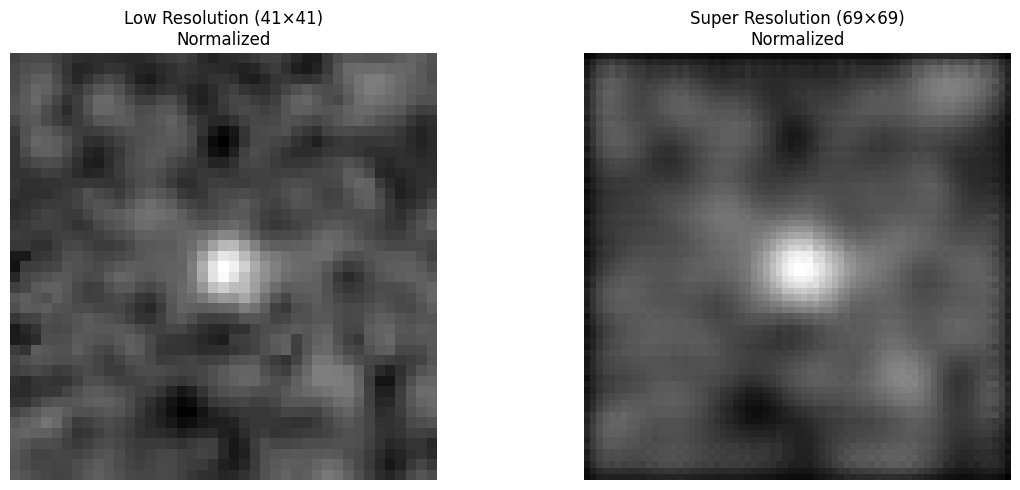

Processed image 5/20


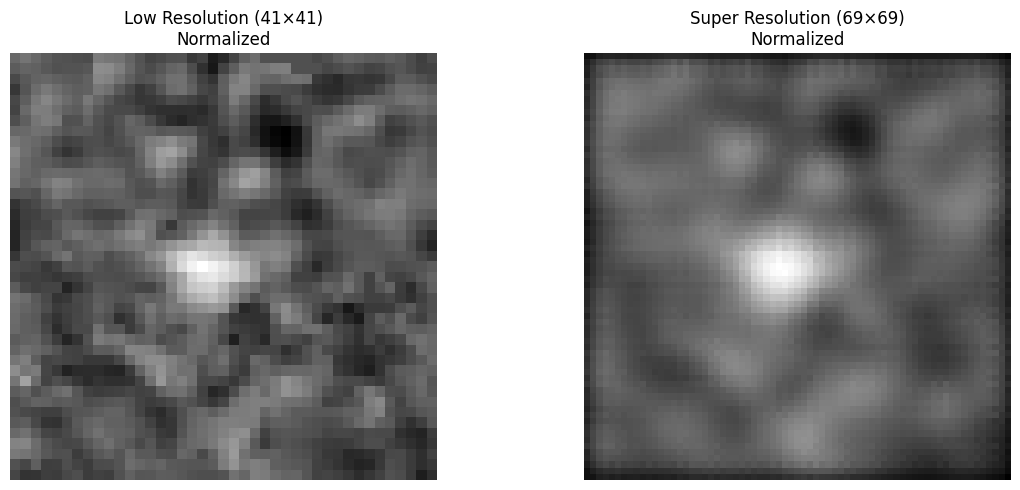

Processed image 6/20


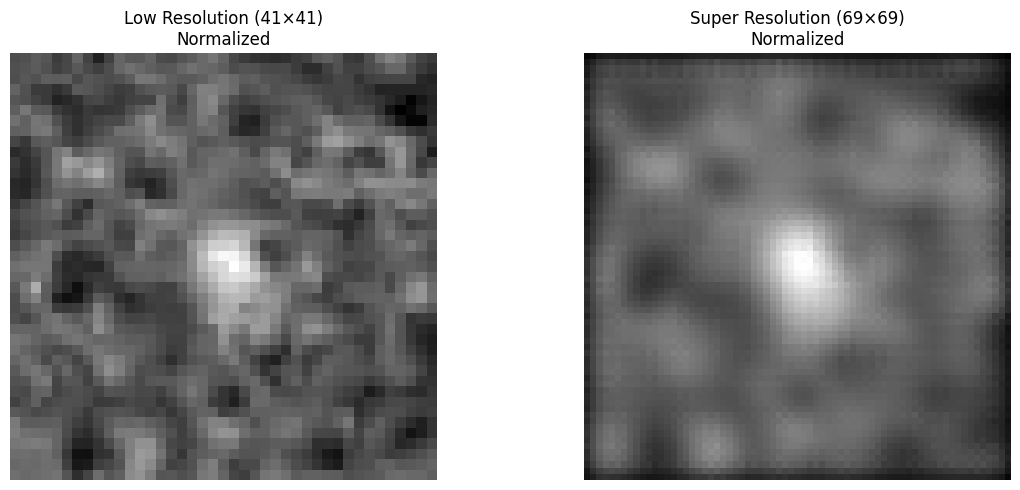

Processed image 7/20


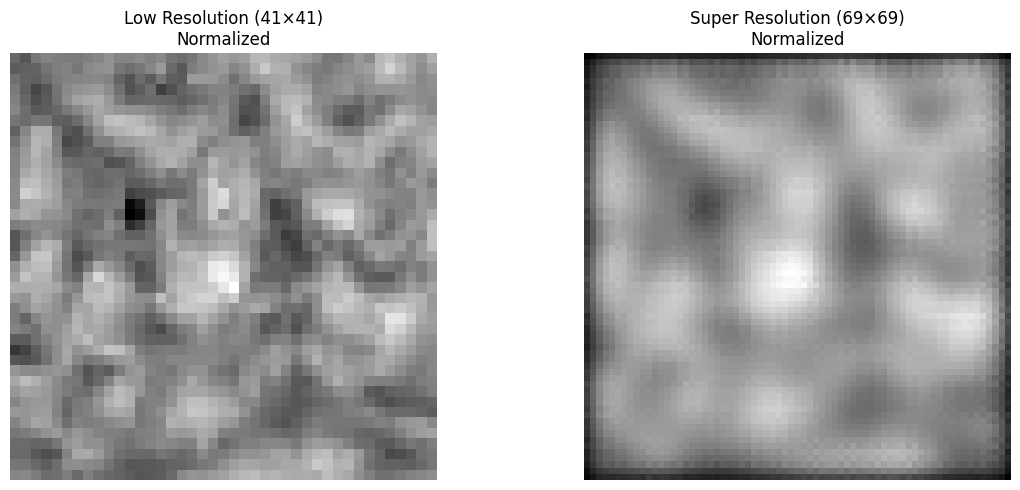

Processed image 8/20


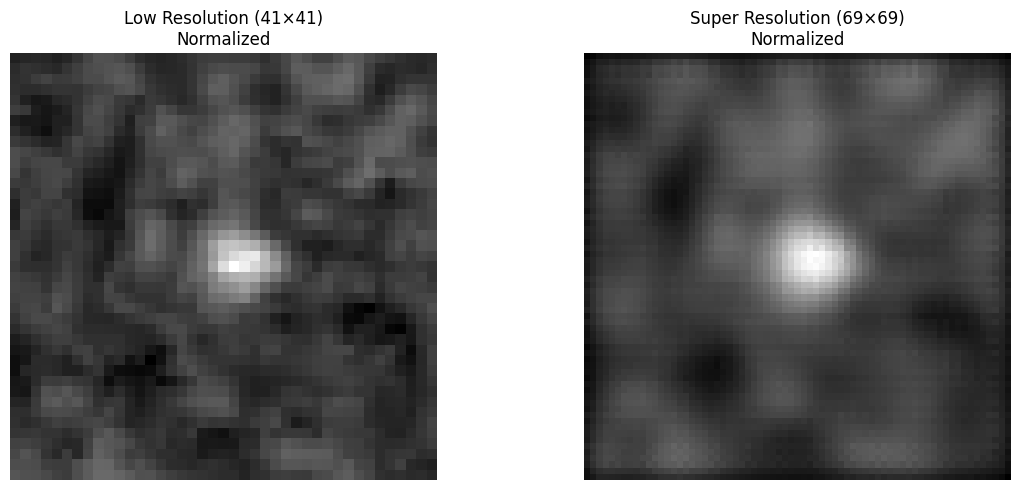

Processed image 9/20


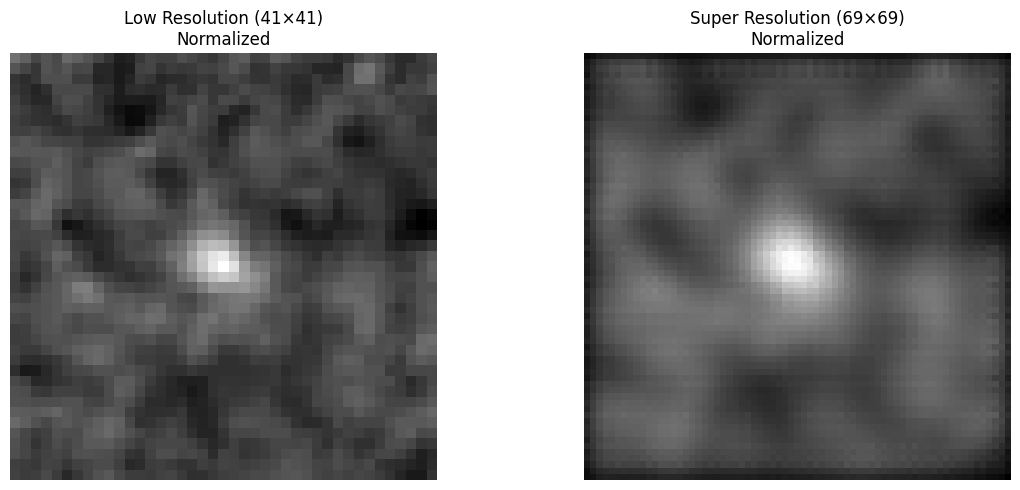

Processed image 10/20


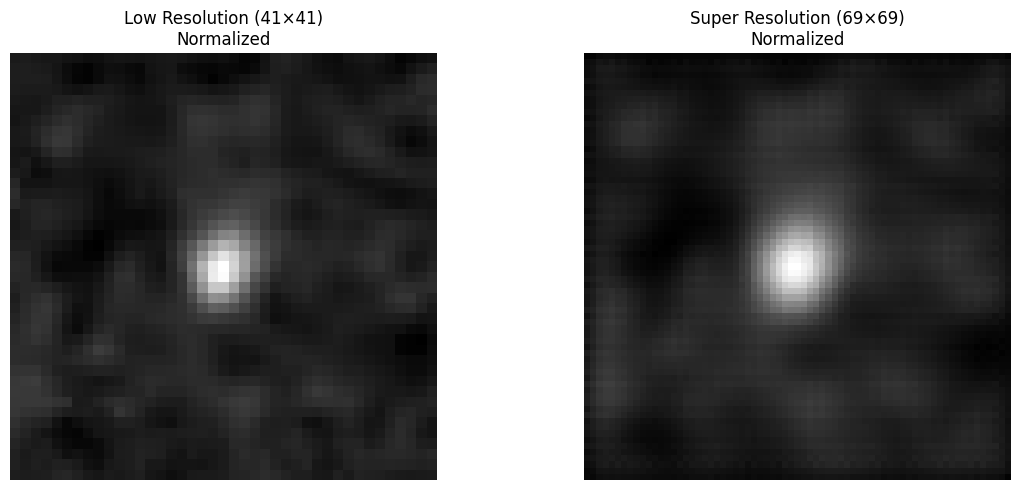

Processed image 11/20


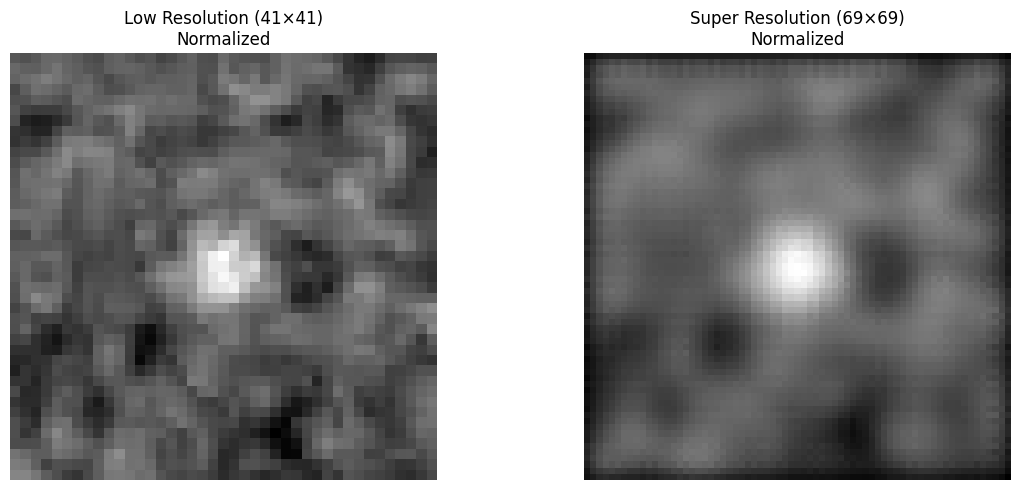

Processed image 12/20


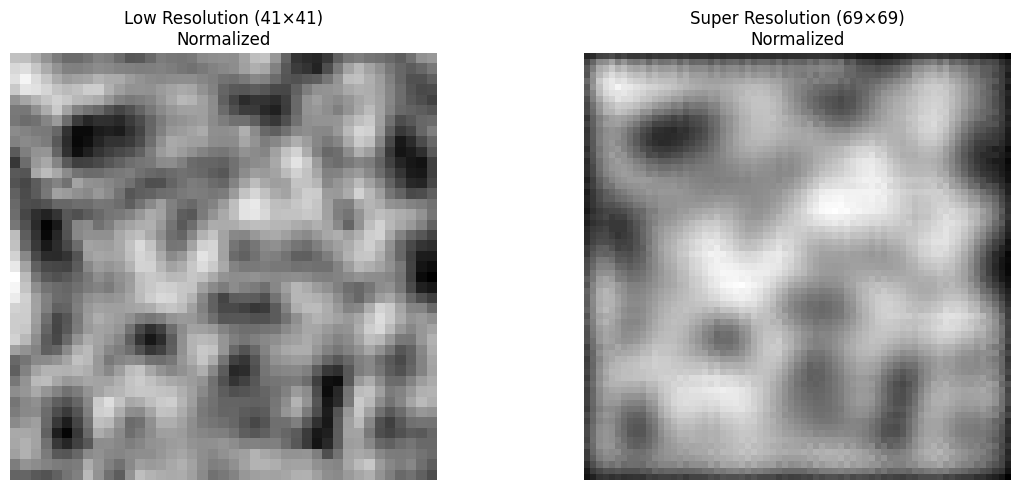

Processed image 13/20


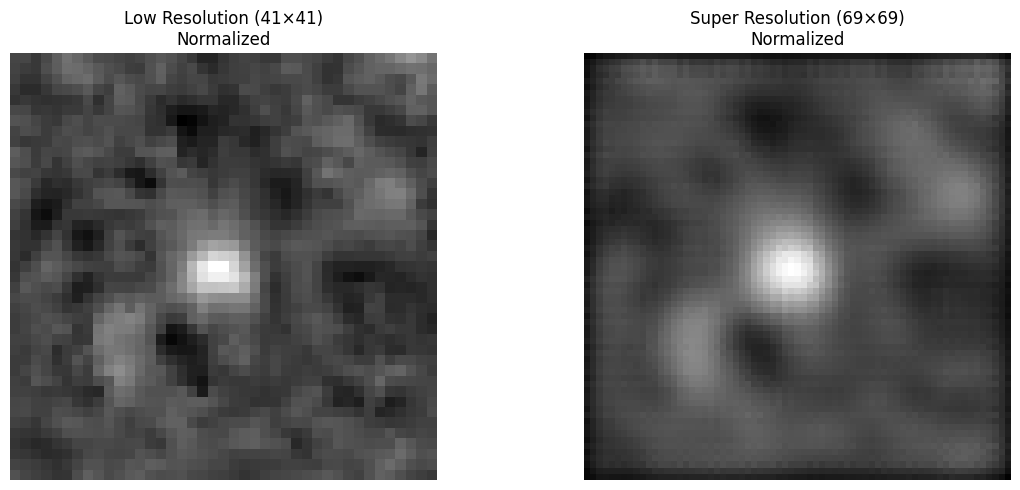

Processed image 14/20


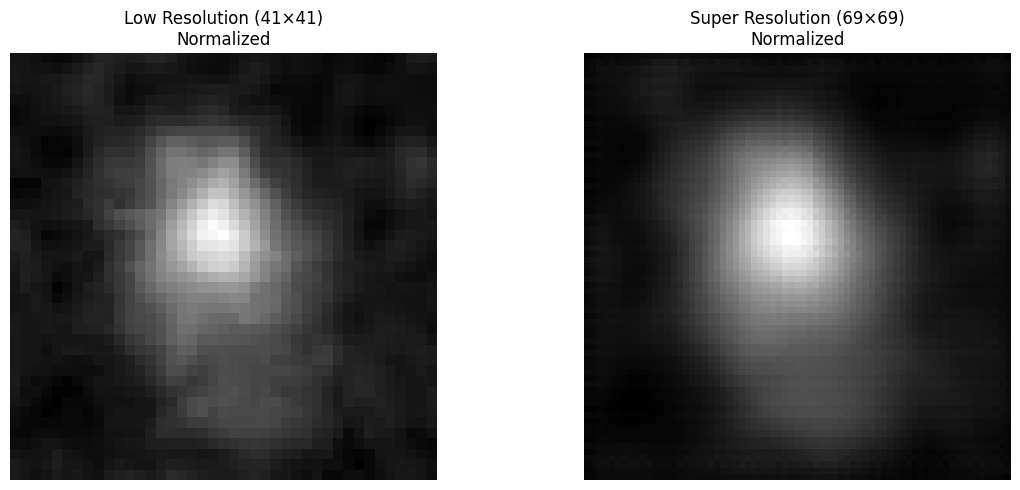

Processed image 15/20


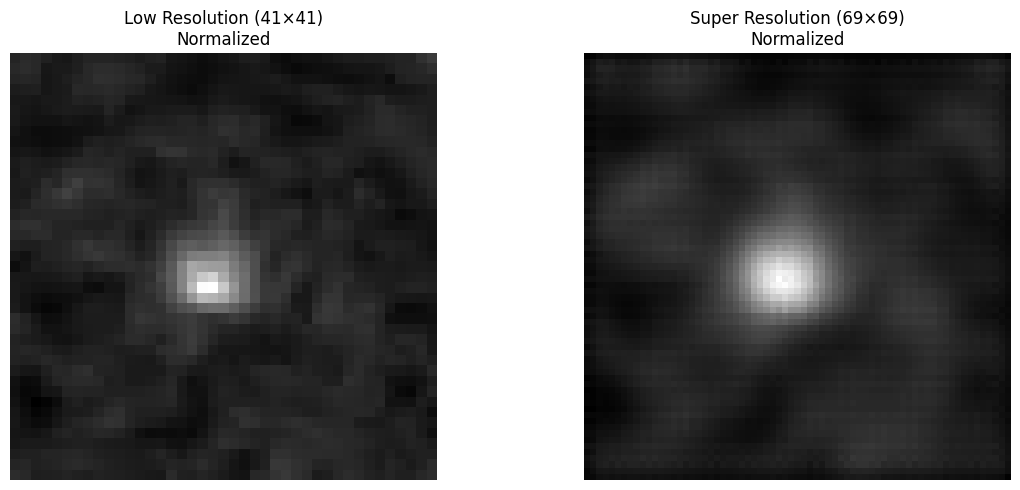

Processed image 16/20


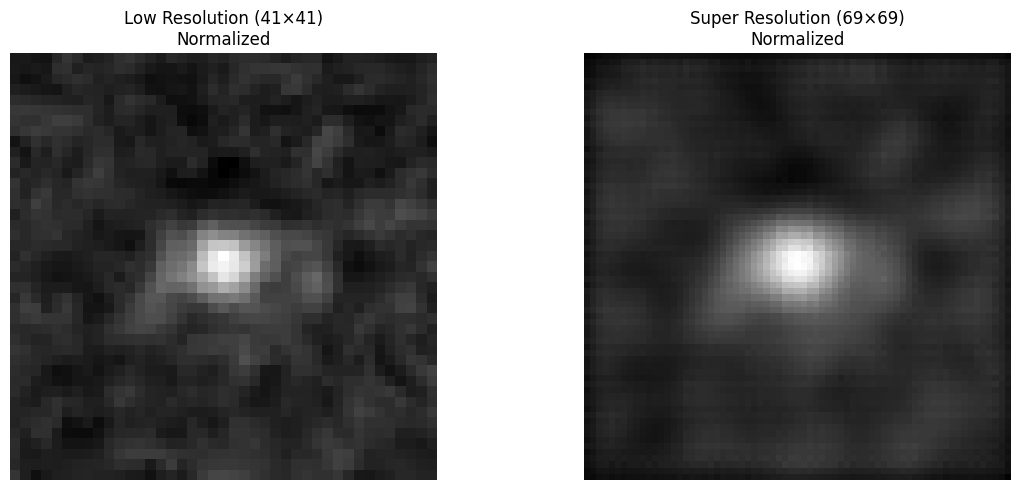

Processed image 17/20


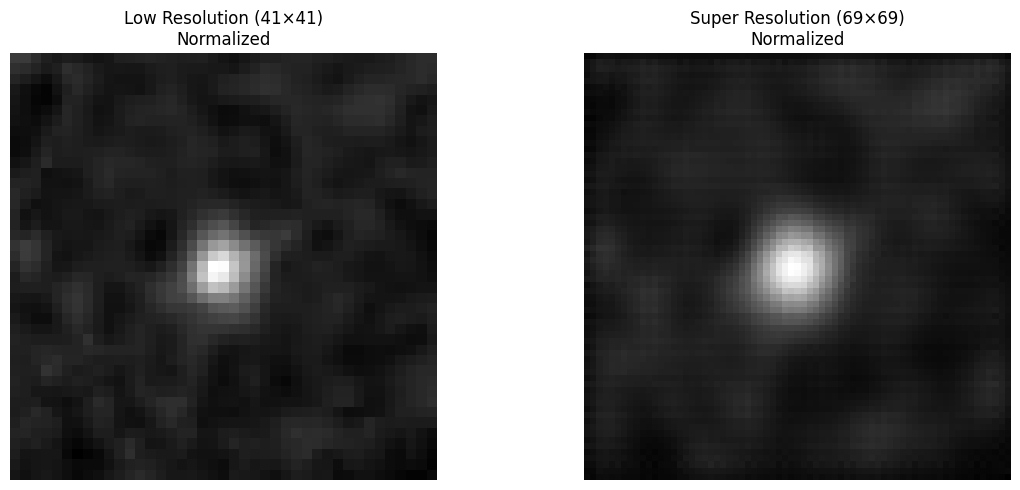

Processed image 18/20


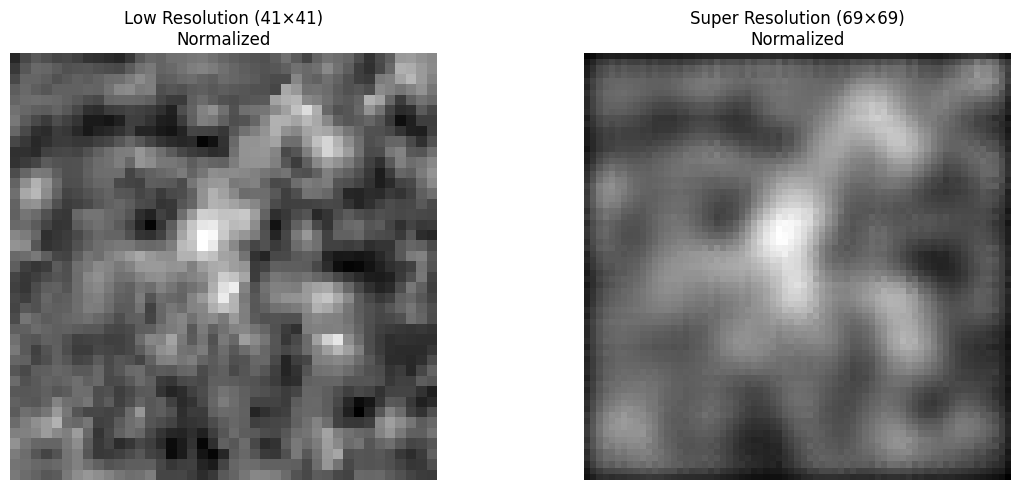

Processed image 19/20


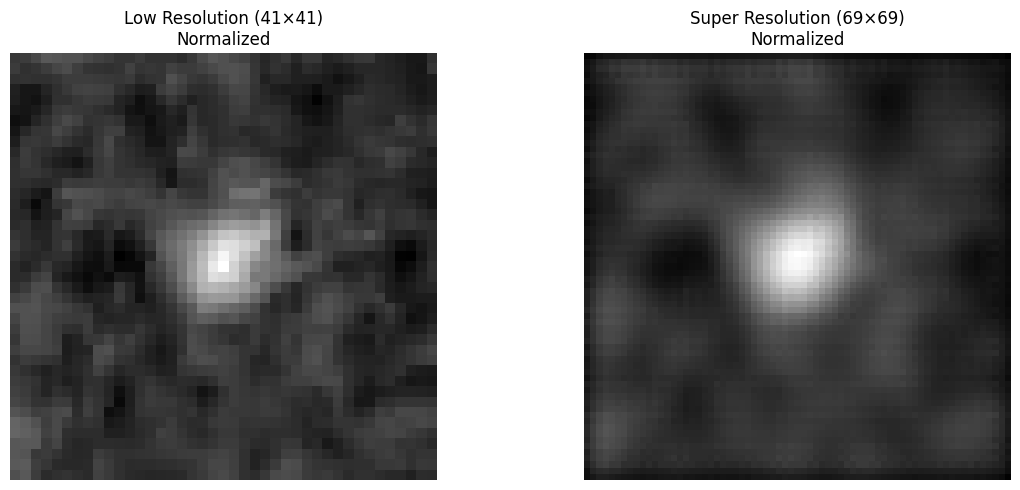

Processed image 20/20
Results saved to ../data/claude_model_output/


In [33]:
trained_model = load_model("claude_model.pth")
test_dataset = TestDataset("../data/euclid_MER_cosmos_41px_Y.npy", normalize_method='flux_preserving')
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)
run_inference(model, test_loader, output_dir='../data/claude_model_output/', max_samples=20, save_individual=False, save_denormalized=False)